## Confusion Matrix

In machine learning, a confusion matrix is a table that is used to evaluate the performance of a classification algorithm. It is a specific table layout that allows visualization of the performance of an algorithm, typically a supervised learning one. Each row of the matrix represents the instances in an actual class while each column represents the instances in a predicted class. The name "confusion matrix" comes from the fact that it shows how confused the model is when making predictions.

It store four values:

- True Positives (TP): The number of instances that were correctly predicted as positive.

- True Negatives (TN): The number of instances that were correctly predicted as negative.

- False Positives (FP): The number of instances that were incorrectly predicted as positive.

- False Negatives (FN): The number of instances that were incorrectly predicted as negative.

Manual implementation of confusion matrix:

In [5]:
import numpy as np
import pandas as pd

# A is for positive and B is for Negative
true_value = np.array(['A', 'B', 'A', 'B', 'B', 'B', 'A', 'A', 'A', 'B', 'B', 'A', 'B', 'B', 'B'])
predict_value = np.array(['A', 'A', 'B', 'A', 'B', 'B', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'B'])

# Replace the categoriy to numerical
true_value = np.where(true_value == 'B', 1, 0)
predict_value = np.where(predict_value == 'B', 1, 0)
# Make sure the positive is at the front by reversing
unique_labels = np.unique(true_value)[::-1] 

In [6]:
# Construct the binary confusion matrix by hand
def get_confusion_matrix(y_true, y_pred, labels):
  confusion_matrix = np.zeros((len(labels), len(labels)))
  # True Positives (TPs) and True Negatives (TNs)
  for i in range(len(labels)):
    for j in range(len(y_true)):
      if y_true[j] == labels[i] and y_pred[j] == labels[i]:
        confusion_matrix[i, i] += 1
      # False Positives (FPs)
      elif y_true[j] != labels[i] and y_pred[j] == labels[i]:
        # If the true_label is Positive (1) -> unique_labels[0]
        # False Negatives (FNs)
        if labels[i] == unique_labels[0]:
          confusion_matrix[0, 1] += 1
        else:  # False Positives (FPs)
          confusion_matrix[1, 0] += 1

  return confusion_matrix

get_confusion_matrix(true_value, predict_value, unique_labels)

array([[3., 1.],
       [6., 5.]])

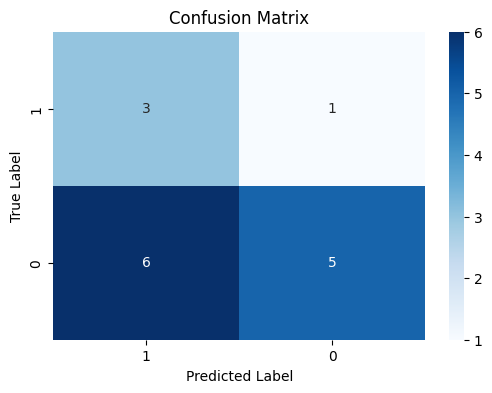

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot
confusion_matrix = get_confusion_matrix(true_value, predict_value, unique_labels)
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix, annot=True, cmap="Blues", 
            xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Evaluating the performance of a classification model using a confusion matrix can provide insights into the types of errors the model is making. By analyzing the values in the confusion matrix, we can calculate various performance metrics such as accuracy, precision, recall, and F1-score, which help us understand how well the model is performing on the given dataset.

Accuracy:

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

Precision:
$$
\text{Precision} = \frac{TP}{TP + FP}
$$

Recall:
$$
\text{Recall} = \frac{TP}{TP + FN}
$$

F1-Score:
$$
\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

Specificity:
$$
\text{Specificity} = \frac{TN}{TN + FP}
$$

In [8]:
# Evaluation metrics
conf_matrix = get_confusion_matrix(true_value, predict_value, unique_labels)
TP = conf_matrix[0, 0]
FP = conf_matrix[0, 1]
FN = conf_matrix[1, 0]
TN = conf_matrix[1, 1]
print(f"TP = {TP}; TN = {TN}; FP = {FP}; FN = {FN}")
print(f'Accuracy: {(TP + TN) / (TP + FP + FN + TN)}')
print(f'Precision: {TP / (TP + FP)}')
print(f'Recall: {TP / (TP + FN)}')
print(f'Specificity: {TN / (TN + FP)}')
print(f'F1 Score: {2 * TP / (2 * TP + FP + FN)}')

TP = 3.0; TN = 5.0; FP = 1.0; FN = 6.0
Accuracy: 0.5333333333333333
Precision: 0.75
Recall: 0.3333333333333333
Specificity: 0.8333333333333334
F1 Score: 0.46153846153846156


Confusion Matric for Multi-Class Classification can be represented as a matrix where the rows represent the actual classes and the columns represent the predicted classes. Each cell in the matrix contains the count of instances that belong to a particular actual class and were predicted as a particular predicted class. The diagonal cells (from top-left to bottom-right) represent the true positives for each class, while the off-diagonal cells represent the false positives and false negatives for each class.

In terms of a multi-class confusion matrix, the following definitions apply:

- True positives (TP): The number of instances that were correctly predicted as belonging to a particular class.

- False positives (FP): The number of instances that were incorrectly predicted as belonging to a particular class.

- False negatives (FN): The number of instances that belong to a particular class but were incorrectly predicted as belonging to a different class.

- True negatives (TN): The number of instances that were correctly predicted as not belonging to a particular class.

In [9]:
import numpy as np

true_value = np.array([
    'Cat', 'Cat', 'Cat', 'Cat', 'Cat', 'Cat', 'Cat', 'Cat', 'Cat', 'Cat', 
    'Dog', 'Dog', 'Dog', 'Dog', 'Dog', 'Dog', 'Dog', 'Dog', 'Dog', 'Dog', 'Dog', 'Dog', 'Dog', 
    'Horse', 'Horse', 'Horse', 'Horse', 'Horse', 'Horse', 'Horse', 'Horse', 'Horse'
])
predict_value = np.array([
    'Cat', 'Cat', 'Cat', 'Cat', 'Cat', 'Cat', 'Cat', 'Cat', 'Dog', 'Dog',
    'Cat', 'Dog', 'Dog', 'Dog', 'Dog', 'Dog', 'Dog', 'Dog', 'Dog', 'Dog', 'Dog', 'Horse', 'Horse',
    'Cat', 'Horse', 'Horse', 'Horse', 'Horse', 'Horse', 'Horse', 'Horse', 'Horse'
])

# Total samples
print(f"Total Samples: {len(true_value)}")

Total Samples: 32


In [10]:
unique_labels = np.unique(true_value).tolist()
# Replace the labels
for i in range(len(unique_labels)):
    true_value[true_value == unique_labels[i]] = i
    predict_value[predict_value == unique_labels[i]] = i

true_value = np.array(true_value, dtype=int)
predict_value = np.array(predict_value, dtype=int)

In [11]:
def multi_confusion_matrix(true_value, predict_value, labels):
  confusion_matrix = np.zeros((len(labels), len(labels)))
  tp = []
  for j in range(len(unique_labels)):
      tp_count = 0
      for k in range(len(true_value)):
          # Catch the true positive
          if true_value[k] == j and predict_value[k] == j:
              tp_count += 1  # Count and then append
          # Finally, count the remaining entries
          elif true_value[k] == j and predict_value[k] != j:
              confusion_matrix[true_value[k], predict_value[k]] += 1
      # Substitute the tp to the diagonal entry
      confusion_matrix[j, j] = tp_count
    
  return confusion_matrix

In [12]:
def get_components(confusion_matrix, k):
    tp = confusion_matrix[k, k]
    fp = confusion_matrix[:, k].sum() - tp
    fn = confusion_matrix[k, :].sum() - tp
    tn = confusion_matrix.sum() - (tp + fp + fn)
    return tp, fp, fn, tn

In [13]:
def evaluation(labels):
  confusion_matrix = multi_confusion_matrix(true_value, predict_value, labels)
  for i in range(len(labels)): # Iterate over integer indices
      print("Label", labels[i]) # Use the index to get the string label for printing
      tp, fp, fn, tn = get_components(confusion_matrix, i)
      accuracy = (tp + tn) / (tp + tn + fp + fn)
      precision = tp / (tp + fp)
      recall = tp / (tp + fn)
      specificity = tn / (tn + fp)
      f1_score = (2 * recall * precision) / (recall + precision)
      print(f"- TP: {tp}; FP: {fp}; FN: {fn}; TN: {tn}")
      print(f"- Accuracy: {accuracy}")
      print(f"- Precision: {precision}")
      print(f"- Recall: {recall}")
      print(f"- Specificity: {specificity}")
      print(f"- F1 Score: {f1_score}")

In [14]:
multi_confusion_matrix(true_value, predict_value, unique_labels)
evaluation(unique_labels)

Label Cat
- TP: 8.0; FP: 2.0; FN: 2.0; TN: 20.0
- Accuracy: 0.875
- Precision: 0.8
- Recall: 0.8
- Specificity: 0.9090909090909091
- F1 Score: 0.8000000000000002
Label Dog
- TP: 10.0; FP: 2.0; FN: 3.0; TN: 17.0
- Accuracy: 0.84375
- Precision: 0.8333333333333334
- Recall: 0.7692307692307693
- Specificity: 0.8947368421052632
- F1 Score: 0.8
Label Horse
- TP: 8.0; FP: 2.0; FN: 1.0; TN: 21.0
- Accuracy: 0.90625
- Precision: 0.8
- Recall: 0.8888888888888888
- Specificity: 0.9130434782608695
- F1 Score: 0.8421052631578948


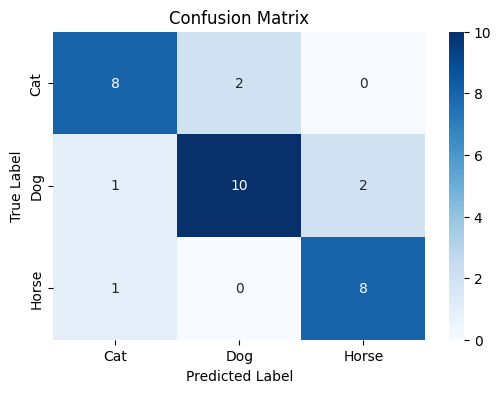

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot
confusion_matrix = multi_confusion_matrix(true_value, predict_value, unique_labels)
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix, annot=True, cmap="Blues", 
            xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Macro Metrics are calculated by averaging the metric across all classes, treating each class equally regardless of its support (the number of instances in that class). This means that each class contributes equally to the final metric, which can be useful when you want to evaluate the performance of a model across all classes without being biased by class imbalance.

In [16]:
# Find the macro metrics
def macro_evaluation(labels):
  confusion_matrix = multi_confusion_matrix(true_value, predict_value, labels)
  precision = []
  recall = []
  specificity = []
  f1_score = []
  for i in range(len(labels)): # Iterate over integer indices
      tp, fp, fn, tn = get_components(confusion_matrix, i)
      accuracy = (tp + tn) / (tp + tn + fp + fn)
      precision.append(tp / (tp + fp))
      recall.append(tp / (tp + fn))
      specificity.append(tn / (tn + fp))
      f1_score.append((2 * recall[i] * precision[i]) / (recall[i] + precision[i]))
  # Find Macro
  precision = np.mean(precision)
  recall = np.mean(recall)
  specificity = np.mean(specificity)
  f1_score = np.mean(f1_score)
  return f"Macro Precision: {precision},\nMacro Recall: {recall},\nMacro Specificity: {specificity},\nMacro F1-Score: {f1_score}"

      
print(macro_evaluation(unique_labels))

Macro Precision: 0.8111111111111112,
Macro Recall: 0.8193732193732194,
Macro Specificity: 0.9056237431523472,
Macro F1-Score: 0.8140350877192982
